<a href="https://colab.research.google.com/github/s-aruneshwaran/Plant-Disease-Detection-CNN/blob/main/Plant_disease_prediction_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounting the drive, importing dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Fetching the dataset from the drive

In [ ]:
!ls "/content/drive/MyDrive/Minor project"

 Dataset   Model  'Plant disease prediction.ipynb'  'Streamlit application'


Importing the libraries

In [ ]:
from keras.utils import img_to_array
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import cv2
import random
import os
from os import listdir
from PIL import Image
import tensorflow as tf
from keras.preprocessing import image
from tensorflow.keras.utils import img_to_array, array_to_img
from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dropout, Dense
from sklearn.model_selection import train_test_split
from keras.models import model_from_json
from keras.utils import to_categorical

Visualing , resizing the images

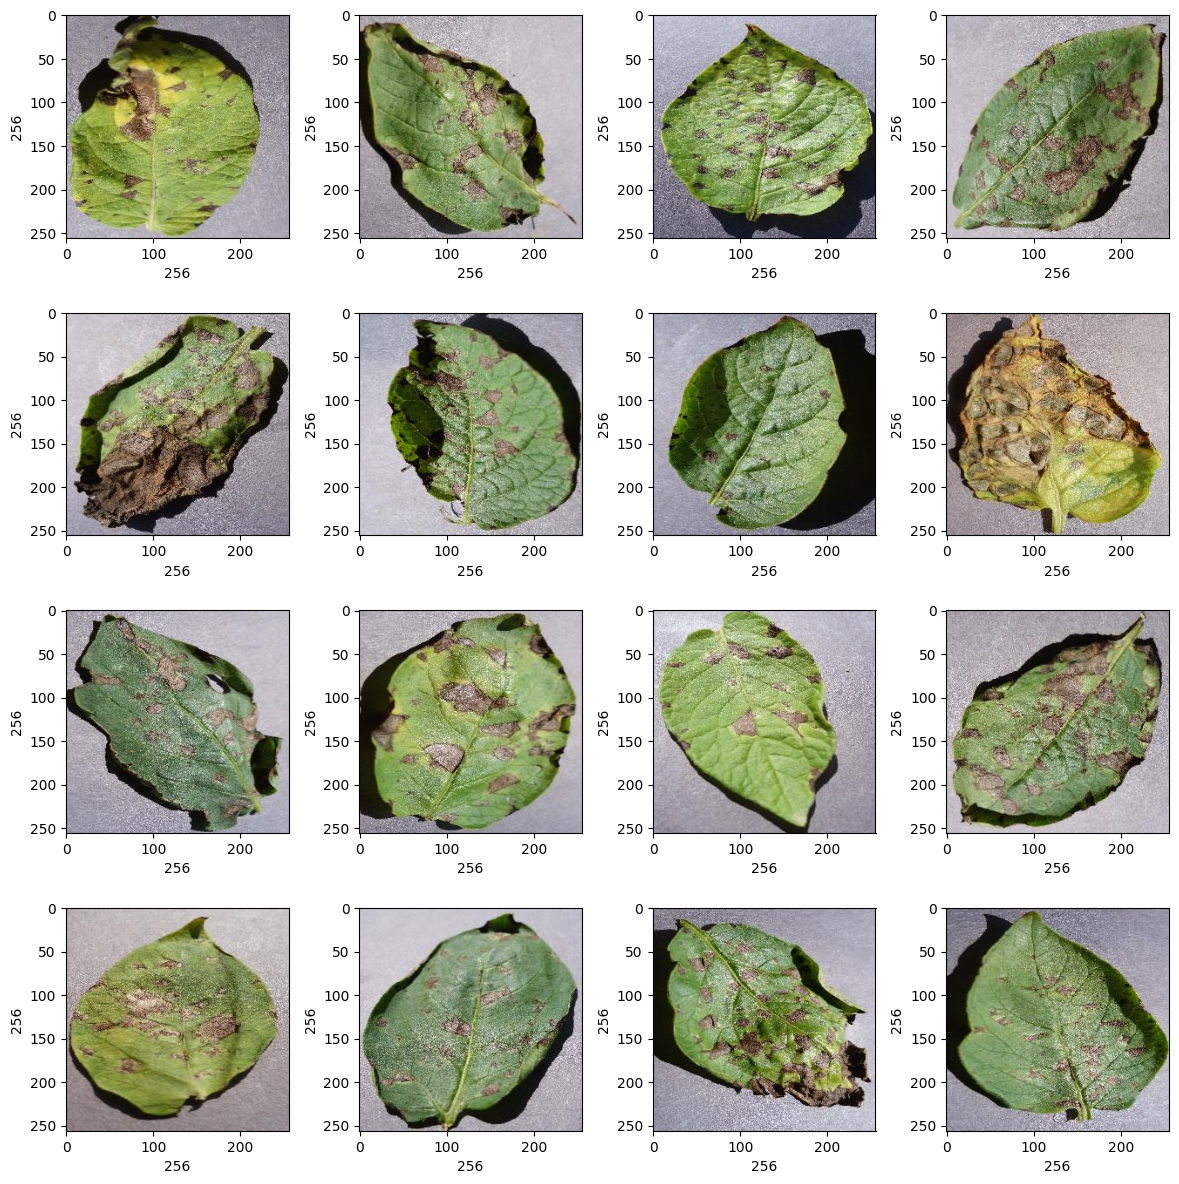

In [ ]:
plt.figure(figsize=(12,12))
path = "/content/drive/MyDrive/Minor project/Dataset/Potato___Early_blight"
for i in range(1,17):
  plt.subplot(4,4,i)
  plt.tight_layout()
  rand_img = imread(path +'/'+ random.choice(sorted(os.listdir(path))))
  plt.imshow(rand_img)
  plt.xlabel(rand_img.shape[1], fontsize = 10) #image width
  plt.ylabel(rand_img.shape[0], fontsize = 10) #image height

Images to NumPy array and normalize

In [ ]:
def convert_image_to_array(image_dir):
  try:
    image = cv2.imread(image_dir)
    if image is not None :
      image = cv2.resize(image, (256,256))
      return img_to_array(image)
    else:
      return np.array([])
  except Exception as e:
    print(f"Error : {e}")
    return None

Let's convert all images into numpy array

In [ ]:
dir = "/content/drive/MyDrive/Minor project/Dataset"
image_list, label_list = [], []
all_labels = ['Tomato-Bacterial_Spot', 'Potato-Early_blight', 'Corn-Common_rust']
binary_labels = [0,1,2]
temp = -1

#Reading , converting images to numpy array
for directory in ['Tomato___Bacterial_spot', 'Potato___Early_blight', 'Corn_(maize)___Common_rust_']:
  plant_image_list = listdir(f"{dir}/{directory}")
  temp += 1
  for files in plant_image_list:
    image_path = f"{dir}/{directory}/{files}"
    image_list.append(convert_image_to_array(image_path))
    label_list.append(binary_labels[temp])

Visualizing class count , check for class imbalance

In [ ]:
label_counts = pd.DataFrame(label_list).value_counts()
label_counts.head()

0    300
1    300
2    300
dtype: int64

In [ ]:
image_list[0].shape

(256, 256, 3)

checking the total no.of images which is the length of labels list

Splitting the dataset into train, validate, test sets

Using sklearn train_test split to split the dataset into testing, training data. I have taken test size as 0.2 so my data will be divided into 80% training and 20% testing data

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(image_list, label_list, test_size=0.2, random_state = 10)

Normalize the dataset of images. Pixel value ranges from 0 - 255 so we will divide each image pixel with 255 to normalize dataset

In [ ]:
x_train = np.array(x_train, dtype=np.float16) / 255.0
x_test = np.array(x_test, dtype=np.float16) / 255.0
x_train = x_train.reshape( -1, 256,256,3)
x_test = x_test.reshape( -1, 256,256,3)

Perform One-Hot encoding on target variable

In [ ]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

Create the model architecture, compile the model and then fit it using the training data :

We will create a network architecture for the model. We have used the different types of layers according to their features namely Conv_2D (It is used to create a convolutional kernel that is convolved with the input layer to produce the output tensor), Max_Pooling2D (It is a downsampling techique which takes out the maximum value over the window defined by poolsize), Flatten (It flattens the input and creates a 1D output), Dense (dense layer produce the output as the dot product of input and kernel).

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), padding="same",input_shape=(256,256,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(3, 3)))
model.add(Conv2D(16, (3, 3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(8, activation="relu"))
model.add(Dense(3, activation="softmax"))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 85, 85, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 85, 85, 16)        4624      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 42, 42, 16)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 28224)             0         
                                                                 
 dense (Dense)               (None, 8)                 2

When compiling the model we need to set the type of loss which will be Categorical Crossentropy for our model along with this we also need to set the optimizer as adam and metrics as accuracy respectively.

In [ ]:
model.compile(loss = 'categorical_crossentropy', optimizer = Adam(0.0001),metrics=['accuracy'])

Now, we split training data into validation and training data

In [ ]:
x_train, x_val, y_train, y_val= train_test_split(x_train, y_train, test_size = 0.2, random_state = 10)

Fitting the model with the data and finding out the accuracy at each epoch to see how our model is learning. Now we will train our model on 10 epochs and a batch size of 128. You can try using more no.of epochs to increase accuracy but here we can see that the model has aleady reached a high accuracy so we don't need to run it for more. During each epochs we can see how the model is performing by viewing the training and validation accuracy.

In [ ]:
# Model training
epochs = 50
batch_size = 128
history = model.fit(x_train, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val, y_val))

Epoch 1/50
5/5 [==============================] - 37s 7s/step - loss: 0.5232 - accuracy: 0.6597 - val_loss: 0.5522 - val_accuracy: 0.6458
Epoch 2/50
5/5 [==============================] - 36s 7s/step - loss: 0.5031 - accuracy: 0.6667 - val_loss: 0.5405 - val_accuracy: 0.6458
Epoch 3/50
5/5 [==============================] - 39s 8s/step - loss: 0.4923 - accuracy: 0.6667 - val_loss: 0.5232 - val_accuracy: 0.6458
Epoch 4/50
5/5 [==============================] - 36s 7s/step - loss: 0.4765 - accuracy: 0.6684 - val_loss: 0.5123 - val_accuracy: 0.6458
Epoch 5/50
5/5 [==============================] - 38s 7s/step - loss: 0.4629 - accuracy: 0.6667 - val_loss: 0.5063 - val_accuracy: 0.6458
Epoch 6/50
5/5 [==============================] - 36s 7s/step - loss: 0.4512 - accuracy: 0.6788 - val_loss: 0.4877 - val_accuracy: 0.6458
Epoch 7/50
5/5 [==============================] - 38s 7s/step - loss: 0.4374 - accuracy: 0.6997 - val_loss: 0.4754 - val_accuracy: 0.6597
Epoch 8/50
5/5 [==================

Saving the model

In [ ]:
model.save("/content/drive/MyDrive/Minor project/Model/plant_disease_model.h5")

Plotting the accuracy and loss against each epoch

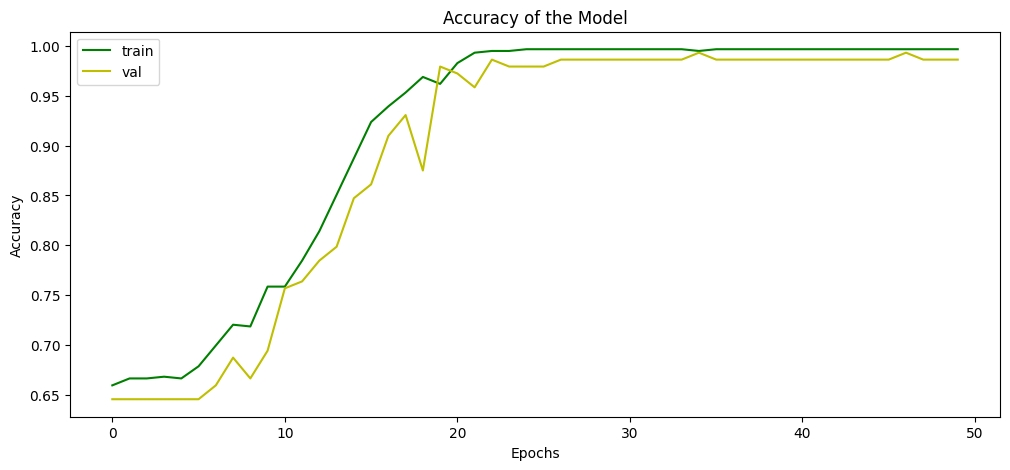

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], color='g')
plt.plot(history.history['val_accuracy'], color='y')
plt.title('Accuracy of the Model')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train','val'])
plt.show()

Perform Model evaluation to know the accuracy of the model

In [ ]:
print("Calculation of the model accuracy")
scores = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {scores[1]*100}")

Calculation of the model accuracy
6/6 [==============================] - 5s 865ms/step - loss: 0.0416 - accuracy: 0.9944
Test Accuracy: 99.44444298744202


Making predictions on testing data

In [ ]:
y_pred = model.predict(x_test)

6/6 [==============================] - 3s 482ms/step


Visualizing the original & Predicted labels for test images

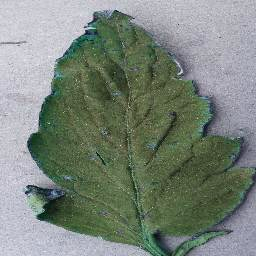

In [ ]:
img = array_to_img(x_test[11])
img

Finding max value from prediction list and comparing Original value vs Predicted value

In [ ]:
print("Original Label: ",all_labels[np.argmax(y_test[11])])
print("Predicted Label: ",all_labels[np.argmax(y_pred[4])])
print(y_pred[2])

Original Label:  Tomato-Bacterial_Spot
Predicted Label:  Tomato-Bacterial_Spot
[2.8398555e-09 7.5014716e-05 9.9992496e-01]


In [ ]:
for i in range(50):
  print (all_labels[np.argmax(y_test[i])], "-", all_labels[np.argmax(y_pred[i])])

Potato-Early_blight - Potato-Early_blight
Tomato-Bacterial_Spot - Tomato-Bacterial_Spot
Corn-Common_rust - Corn-Common_rust
Tomato-Bacterial_Spot - Tomato-Bacterial_Spot
Tomato-Bacterial_Spot - Tomato-Bacterial_Spot
Corn-Common_rust - Corn-Common_rust
Tomato-Bacterial_Spot - Tomato-Bacterial_Spot
Potato-Early_blight - Potato-Early_blight
Potato-Early_blight - Potato-Early_blight
Potato-Early_blight - Potato-Early_blight
Potato-Early_blight - Potato-Early_blight
Tomato-Bacterial_Spot - Tomato-Bacterial_Spot
Corn-Common_rust - Corn-Common_rust
Corn-Common_rust - Corn-Common_rust
Tomato-Bacterial_Spot - Tomato-Bacterial_Spot
Corn-Common_rust - Corn-Common_rust
Tomato-Bacterial_Spot - Tomato-Bacterial_Spot
Tomato-Bacterial_Spot - Tomato-Bacterial_Spot
Corn-Common_rust - Corn-Common_rust
Corn-Common_rust - Corn-Common_rust
Corn-Common_rust - Corn-Common_rust
Tomato-Bacterial_Spot - Tomato-Bacterial_Spot
Tomato-Bacterial_Spot - Tomato-Bacterial_Spot
Corn-Common_rust - Corn-Common_rust
Potato

Conclusion:

Implementation of project started with loading the dataset into google colab from google drive and visualizing the images. Normalizing is an important step when working with any type of dataset. After that we created a CNN Model which is further used for predicting the plant leaf diseases using the image supplied to the model. This model is very beneficial as it can be used by various different agricultural comapanies and farmers to increase their yield and stop wastage of crops due to the disease.

Now implementing the project using Streamlit.

Streamlit is an open source app framework in python language. It helps us to create sharable web apps for data science and machine learning in a short span of time and is compatible with major python libraries such as scikit-learn, keras, pytorch, numpy, pandas, matplotlib etc.